# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột

print(round(df.isnull().mean(),4))

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alone', 'embark_town', 'deck', 'who', 'class', 'alive', 'adult_male' ]      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)
df = df.drop(columns = leaky)

# print("Các cột còn lại:", list(df.columns))
print("\nCác cột còn lại:", list(df.columns))

survived       0.0000
pclass         0.0000
sex            0.0000
age            0.1987
sibsp          0.0000
parch          0.0000
fare           0.0000
embarked       0.0022
class          0.0000
who            0.0000
adult_male     0.0000
deck           0.7722
embark_town    0.0022
alive          0.0000
alone          0.0000
dtype: float64

Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*'alive' gây rò rỉ target vì đây chính là đáp án, kết quả mà mô hình cần phải trả về dựa vào các features khác, nhưng ở đây đã có sẵn thì model chỉ cần học vẹt cột này thì sẽ trả lời đúng 100% việc hành khách trong tập dataset có sống sốt hay không.*

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print(df.shape)
print("Biến mục tiêu là survived: là biến mà mô hình cần phải dự đoán từ những dữ kiện của biến khác\n")
print(df.info())
print(df.describe())
df.describe(include="object")

(891, 8)
Biến mục tiêu là survived: là biến mà mô hình cần phải dự đoán từ những dữ kiện của biến khác

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.42

C:\Users\Admin\AppData\Local\Temp\ipykernel_42092\3994035649.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

Biến số: age, sibsp, fare, parch

Biến phân loại: survived, sex, embarked

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_counts = df.isnull().sum()
missing_percent = (missing_counts/len(df)*100).round(4)
print(f"{missing_counts}\n{missing_percent}")

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64
survived     0.0000
pclass       0.0000
sex          0.0000
age         19.8653
sibsp        0.0000
parch        0.0000
fare         0.0000
embarked     0.2245
dtype: float64


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |

|age|19.9%| Điền median |Cột age không thiếu quá nhiều nên ta có thể điền dữ liệu vào, ở đây ta sẽ sử dụng median để tránh việc dữ liệu bị lệch bởi các outlier như trẻ em (tuổi rất bé) và người già (tuổi lớn)|

|embarked|0.2%| Điền mode | Embarked ở đây là biến phân loại chữ nên không thể điền mean hay median được, ta sẽ điền mode, coi như khả năng những người thiếu thông tin embarked sẽ lên cảng có nhiều người lên cùng nhất|

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s = s.dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    iqr = Q3 - Q1
    return ((s < Q1 - 1.5*iqr) | (s> Q3 + 1.5 * iqr)).sum()
def dem_outlier_zscore(s, nguong=3.0):
    s =s.dropna()
    z_score = np.abs(stats.zscore(s))
    return (z_score > nguong).sum()

# for col in ["age", "fare"]:
for col in ["age", "fare"]:
    print(f"{col}:\nSố outlier theo IQR: {dem_outlier_iqr(df[col])}\nSố outlier theo z_score: {dem_outlier_zscore(df[col])}\n")
#     ...

age:
Số outlier theo IQR: 11
Số outlier theo z_score: 2

fare:
Số outlier theo IQR: 116
Số outlier theo z_score: 20



**Trả lời 4 (quyết định với outlier của `fare`):**

*(Giữ lại các outlier của fare vì giá vé đắt bất thường có thể là của các khoang hạng nhất, cao cấp,... với mức giá cao hơn hoàn toàn so với hạng phổ thông)*

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

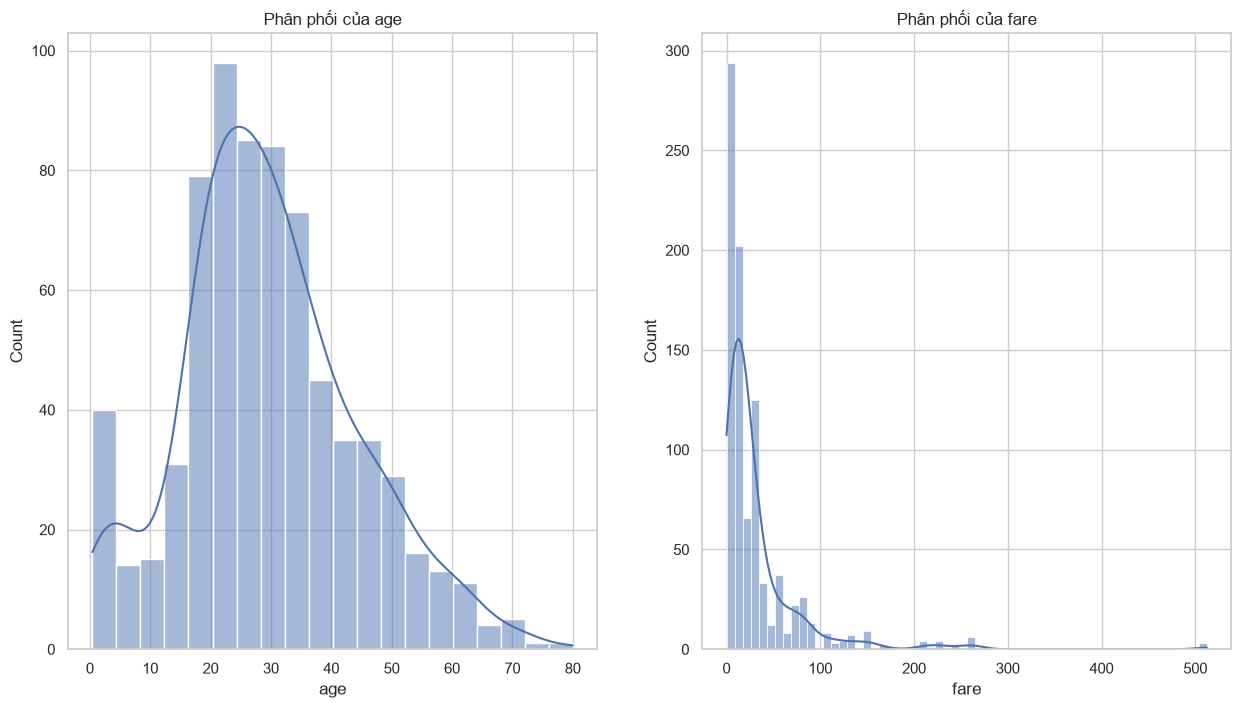

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1,2,figsize=(15,8))
sns.histplot(data= df, x = "age", kde = True, ax=axes[0])
axes[0].set_title("Phân phối của age")
sns.histplot(data=df, x="fare", kde = True, ax=axes[1])
axes[1].set_title("Phân phối của fare")

plt.show()

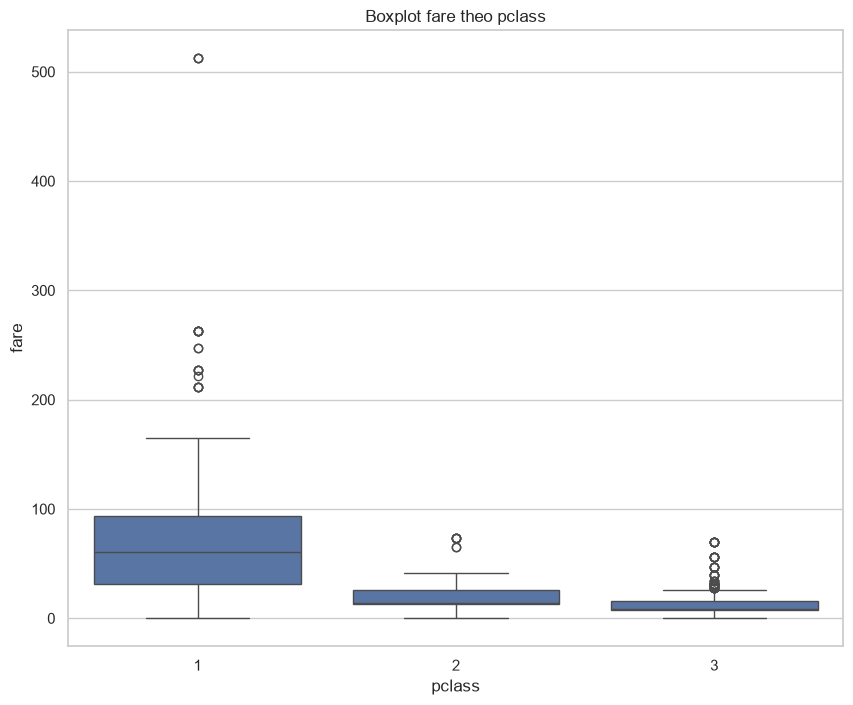

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(10,8))
sns.boxplot(data=df, x="pclass", y="fare")
plt.ylabel("fare")
plt.xlabel("pclass")
plt.title("Boxplot fare theo pclass")
plt.show()



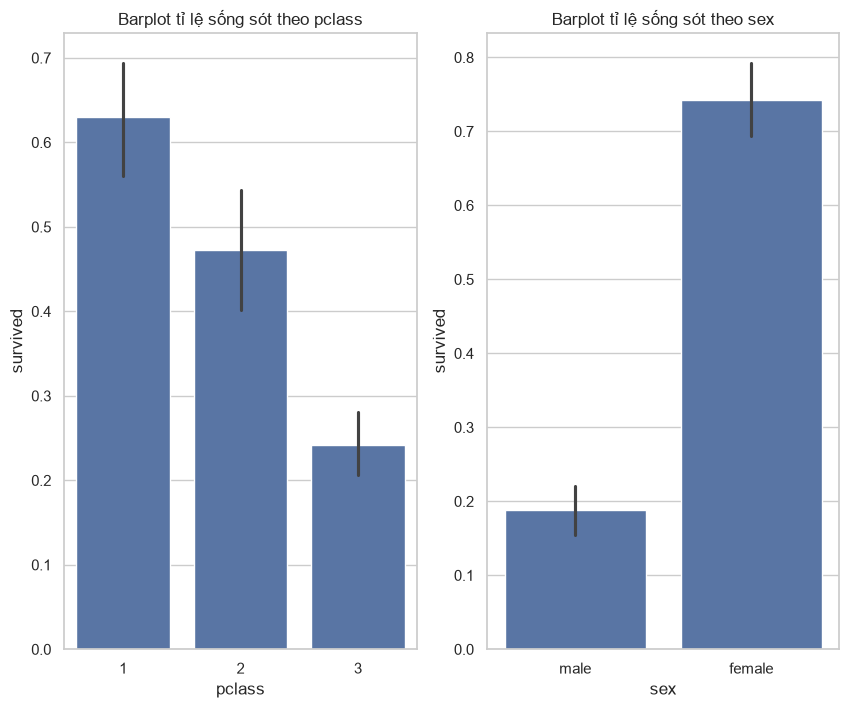

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1,2,figsize=(10,8))
sns.barplot(data=df, x="pclass", y="survived", ax=axes[0])
axes[0].set_title("Barplot tỉ lệ sống sót theo pclass")
sns.barplot(data=df, x="sex",y="survived",ax=axes[1])
axes[1].set_title("Barplot tỉ lệ sống sót theo sex")
plt.show()


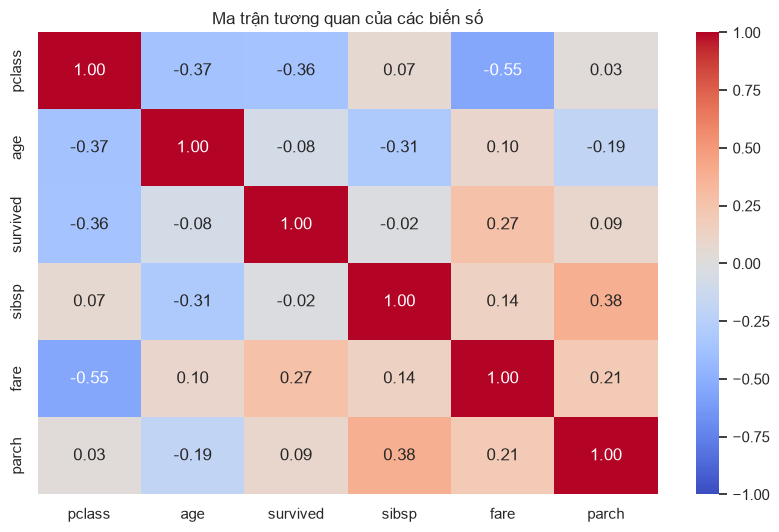

In [10]:
# TODO 5d: Heatmap correlation
numeric_df = df[["pclass","age","survived","sibsp","fare","parch"]].dropna()
corr_df = numeric_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_df, annot= True, cmap="coolwarm", fmt = ".2f", vmin= -1, vmax = 1)
plt.title("Ma trận tương quan của các biến số")
plt.show()



**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: phân phối của 2 biến age và fare đều lệch phải, nhưng ở fare được thể hiện rõ hơn rằng phần lớn đa số mọi người chỉ chi trả mức vé thấp, rất ít người mới có khả năng để mua những mức vé cao cấp. Còn về age thì thể hiện hành khách đa phần là những người trẻ, độ tuổi thành niên, có sự xuất hiện tương đối của trẻ em nhưng người già thì rất ít. 


- Boxplot: Mức giá trung bình của class giảm dần theo thứ tự từ 1 đến 3, độ phân tán mức giá của 2 và 3 khá thấp, song vẫn xuất hiện một số outlier, đặc biệt là ở class 3. Class 1 thì mức giá dao động khá mạnh, cùng với sự xuất hiện của những outlier khá cao, đặc biệt với 1 trường hợp với mức giá >500.

- Bar survival: Tỉ lệ sống sót giảm dần theo từng pclass từ 1 đến 3 điều này có thể là do những người ở hạng vé cao được ưu tiên trong quá trình cứu hộ, còn theo sex thì ta thấy được tỉ lệ sống sót ở nữ cao hơn một cách áp đảo so với nam (~0.75 ở nữ so với ~0.2 ở nam), thể hiện việc "ưu tiên phụ nữ và trẻ em" trong quá trình cứu hộ.

- Heatmap:  Không có sự xuất hiện của hiện tượng đa cộng tuyến khi các biến có độ tương quan khá thấp so với nhau. Cặp biến fare và pclass có độ tương quan nghịch biến: -0.55, có nghĩa là class càng nhỏ (class 1 là cao cấp nhất) thì giá vé sẽ càng lớn, quan trọng nhất thì biến mục tiêu survived tương quan đồng biến với fare: 0.27 có nghĩa giá vé càng cao thì sẽ có khả năng sống sót lớn hơn, và nghịch biến với pclass: -0.36, củng cố kết luận rằng những người có tiền, chi trả cho những khoang cao cấp thì càng dễ sống sót.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=['survived'])
y = df['survived']

# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state= 1)

# X_train, X_val, y_train, y_val = train_test_split(...)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size= 15/85, stratify=y_tmp, random_state=1)

# print("Train/Val/Test:", ...)
print(f"Shape:\nTrain: {X_train.shape}\nValidation: {X_val.shape}\nTest: {X_test.shape}")

# in tỷ lệ survived từng tập
print(f"\nTỉ lệ survived của từng tập:\nTrain: {y_train.sum()/len(y_train)*100:.3f}%\nValidation: {y_val.sum()/len(y_val)*100:.3f}%\nTest: {y_test.sum()/len(y_test)*100:.3f}%")

Shape:
Train: (623, 7)
Validation: (134, 7)
Test: (134, 7)

Tỉ lệ survived của từng tập:
Train: 38.363%
Validation: 38.806%
Test: 38.060%


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    # ("imputer", ...),
    # ("scaler",  ...),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])
pipe_cat = Pipeline([
    # ("imputer", ...),
    # ("onehot",  ...),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', OneHotEncoder())
])

preprocess = ColumnTransformer([
    # ("num", pipe_so,  num_cols),
    # ("cat", pipe_cat, cat_cols),
    # ("ord", "passthrough", ord_cols),
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols)
])

# preprocess.fit(X_train)               # fit CHỈ trên train
# X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))
preprocess.fit(X_train)
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test = preprocess.transform(X_test)
print(X_train_t.shape, list(preprocess.get_feature_names_out()))



(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

*(Fit là quá trình tính toán dữ liệu của mô hình trên tập dữ liệu cho trước, ta cần fit trên tập train (đại diện cho dữ liệu có sẵn) để mô hình khảo sát các giá trị thống kê (Q1,median,Q3,..) cho việc điền dữ liệu khuyết và chuẩn hóa dữ liệu. Nếu quá trình fit này xảy ra ở các tập validation và test (đại diện cho những dữ liệu trong tương lai chưa xảy ra) thì những giá trị mà mô hình vừa tính được sẽ bị ảnh hưởng và sai lệch. Ví dụ cụ thể là việc ta sử dụng dữ liệu của cột age để tìm ra median cho việc điền khuyết, nhưng lại sơ ý fit dữ liệu cột age của tập test, thì quá trình tính toán sẽ bao gồm cả dữ liệu tập test khiến giá trị gốc của median sẽ bị thay đổi, khiến mô hình sẽ học trên một thước đo sai.)*

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print((df['survived'].value_counts(normalize=True)*100).round(3))

survived
0    61.616
1    38.384
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến mục tiêu survived có sự mất cân bằng nhẹ: tử vong chiếm 61.62% và sống sót chiếm 38.38%.
2. Nếu chỉ nhìn accuracy, ta có thể bị đánh lừa trong trường hợp dữ liệu bị mất cân bằng trầm trọng, nếu một lớp chiếm tỉ lệ lên tới 99% thì mô hình chỉ cần dự đoán toàn bộ dữ liệu thuộc lớp đó, khi đó accuracy sẽ là 99% nhưng mô hình sẽ thất bại trong việc nhận diện ra những lớp thiểu số chiếm phần trăm dữ liệu ít hơn.
3. Em nghĩ là nên ưu tiên metric Recall vì: đặt trong bối cảnh quá trình cứu hộ cho những nạn nhân thì việc đoán rằng nạn nhân đã tử vong và không đi tìm thì sẽ mang lại hậu quả rất lớn nếu trong thực tế họ vẫn còn sống, đây là trường hợp mô hình dự đoán bị bỏ sót, việc dự đoán "báo động giả", cho rằng nạn nhân vẫn còn sống trong khi thực tế thì không làm cho việc cứu hộ tốn nhiều tài nguyên hơn, song đây là cái giá rẻ hơn rất nhiều khi so sánh với việc đoán nhầm và bỏ qua mạng người còn sống cần cứu giúp. Hơn nữa, metric Recall ít bị ảnh hưởng bởi việc dữ liệu bị chênh lệch nhẹ như trong tập dữ liệu này vì nó chỉ tập trung đánh giá trên tổng số người thuộc lớp sống sót.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất với tỉ lệ sống sót là pclass với hệ số tương quan nghịch là -0.36, có nghĩa rằng việc hành khách chi trả cho những vé hạng càng cao cấp thì sẽ tăng tỉ lệ sống sót ở mức nhất định.
2. Trong các đặc trưng được giữ lại thì cột age có tỉ lệ thiếu dữ liệu nhiều nhất (gần 20%), và cột này được xử lý bằng cách điền median vào những chỗ trống vì sẽ giảm thiểu sai lệch bởi các outlier (trẻ sơ sinh và người lớn tuổi).
3. Biến mục tiêu survived có sự mất cân bằng nhẹ (xấp xỉ tỉ lệ 6-4). Ở đây em nghĩ việc dataset có độ chênh lệch nhẹ này thì mô hình vẫn có thể sử dụng metric Accuracy được nhưng để nhấn mạnh việc không bỏ sót những hành khách thực sự sống sót thì ta nên sử dụng Recall.
4. Những đặc trưng cần scaling là những biến số: age, fare, sibsp, parch để đưa về cùng một thang đo, tránh việc mô hình bị ảnh hưởng bởi các biến có giá trị lớn (fare dao động lên tới 500 trong khi sibsp chỉ là giá trị nhỏ (0, 1,...)). Đặc trưng cần encoding là các biến phân loại dạng chuỗi: sex, embarked, để chuyển nhãn thành số (là nam giới thì sex_male = 1) thì mô hình mới tính toán bằng các phương pháp toán học được.
5. Một điều em thấy bất ngờ trong dữ liệu đó là tỉ lệ sống sót giữa nam và nữ, em hiểu việc ưu tiên phụ nữ/trẻ em trong cứu hộ là chuyện đương nhiên, dễ hiểu, nhưng không ngờ tỉ lệ lại có độ chênh lệch lớn như vậy: chưa tới 20% ở nam giới và lên tới xấp xỉ 75% ở nữ giới. Cứ như này thì nam giới sẽ không bao giờ dám đi tàu nữa.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

Hệ số tương quan giữa family_sized và survived:
             family_size  survived
family_size     1.000000  0.016639
survived        0.016639  1.000000


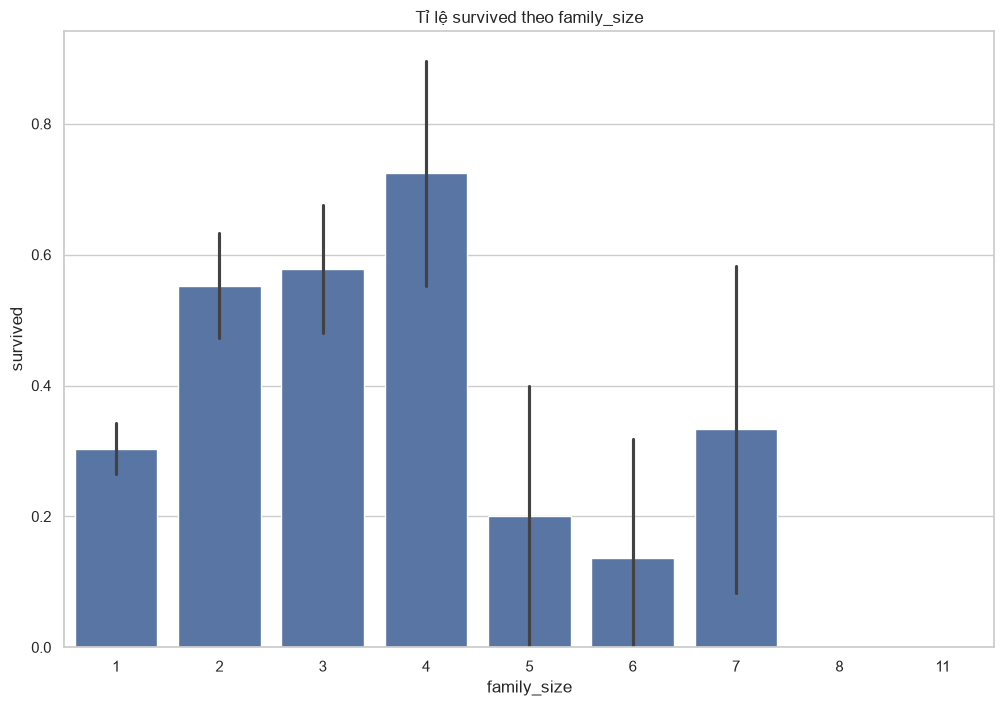

In [14]:
# (tùy chọn) code cho phần Bonus
df['family_size'] = df['sibsp'] + df['parch'] + 1
print(f"Hệ số tương quan giữa family_sized và survived:\n{df[['family_size','survived']].corr()}")
plt.figure(figsize=(12,8))
sns.barplot(data=df, x='family_size',y='survived')
plt.title("Tỉ lệ survived theo family_size")
plt.show()

Đối với hệ số tương quan giữa kích thước gia đình và tỉ lệ sống sót thì dường như không có sự tuyến tính, nghĩa là kích thước gia đình không xác định việc hành khách sẽ sống sót hay không. 

Trong đồ thị thì ta thấy những hành khách có số lượng thành viên trong gia đình trên chuyến tàu từ 2 đến 4 thì có tỉ lệ được cứu khá cao, trong khi những nhóm có số lượng 5 đến 7 thì tỉ lệ lại giảm dần, nguyên nhân thực tế có thể là do việc có quá nhiều thành viên khiến việc tập hợp mọi người và di chuyển khá hỗn loạn, hoặc việc không chịu lên thuyền vì vẫn chưa tìm được những người khác.

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
